In [ ]:
# Import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Define CNN
class CNN(nn.Module):
    def __init__(self, in_channels, num_classes=10):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 8, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(16 * 7 * 7, num_classes)

    # Forward pass
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.reshape(x.shape[0], -1)
        x = self.fc1(x)
        return x

In [4]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [5]:
# Hyperparameters
num_classes = 10
learning_rate = 0.001
batch_size = 64
epochs = 20 # 10

In [6]:
# Load MNIST dataset
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='data/', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='data/', train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 542kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.4MB/s]


In [8]:
# Initialize model, loss, optimizer
model = CNN(in_channels=1, num_classes=num_classes).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
# Training loop with loss and accuracy tracking
epoch_losses = []  # To store average loss per epoch
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    # print(f"\nEpoch [{epoch + 1}/{epochs}]")
    model.train()
    running_loss = 0.0

    # Iterate over batches with progress bar
    for batch_idx, (data, targets) in enumerate(tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{epochs}")):
      data, targets = data.to(device), targets.to(device) # Move data and labels to device

      # Forward pass
      outputs = model(data)
      loss = loss_fn(outputs, targets)  # use your criterion

      # Backward pass and optimization
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      running_loss += loss.item() # Track running loss

    # Compute average loss
    avg_loss = running_loss/len(train_loader)
    epoch_losses.append(avg_loss)  # <-- add this

    # Evaluate Training Accuracy
    model.eval()
    y_true_train, y_pred_train = [], []
    with torch.no_grad():
        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs, 1)
            y_true_train.extend(targets.cpu().numpy())
            y_pred_train.extend(predicted.cpu().numpy())
    train_acc = accuracy_score(y_true_train, y_pred_train)
    train_accuracies.append(train_acc)

    # Evaluate Test Accuracy
    y_true_test, y_pred_test = [], []
    with torch.no_grad():
        for data, targets in test_loader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs, 1)
            y_true_test.extend(targets.cpu().numpy())
            y_pred_test.extend(predicted.cpu().numpy())
    test_acc = accuracy_score(y_true_test, y_pred_test)
    test_accuracies.append(test_acc)

    print(f"Average Loss: {avg_loss:.4f}| "
          f"Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}\n")

# Save trained model
torch.save(model.state_dict(), 'mnist_cnn.pth')
print("Model saved as mnist_cnn.pth")

Training Epoch 1/20: 100%|██████████| 938/938 [00:08<00:00, 113.91it/s]


Average Loss: 0.0582| Train Accuracy: 0.9847 | Test Accuracy: 0.9828



Training Epoch 2/20: 100%|██████████| 938/938 [00:08<00:00, 113.63it/s]


Average Loss: 0.0507| Train Accuracy: 0.9853 | Test Accuracy: 0.9826



Training Epoch 3/20: 100%|██████████| 938/938 [00:07<00:00, 123.04it/s]


...

Average Loss: 0.0142| Train Accuracy: 0.9958 | Test Accuracy: 0.9869



Training Epoch 19/20: 100%|██████████| 938/938 [00:07<00:00, 121.92it/s]


Average Loss: 0.0144| Train Accuracy: 0.9953 | Test Accuracy: 0.9869



Training Epoch 20/20: 100%|██████████| 938/938 [00:07<00:00, 118.27it/s]


Average Loss: 0.0136| Train Accuracy: 0.9967 | Test Accuracy: 0.9886

Model saved as mnist_cnn.pth


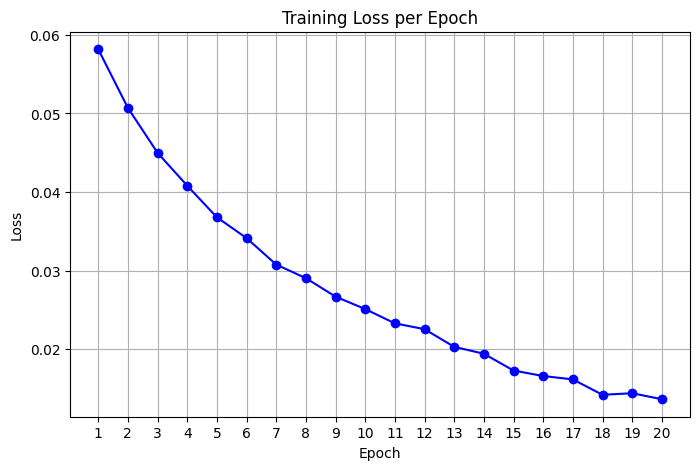

In [11]:
# Plot the training loss curve per epoch
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), epoch_losses, marker='o', color='blue')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, epochs+1))
plt.grid(True)
plt.show()

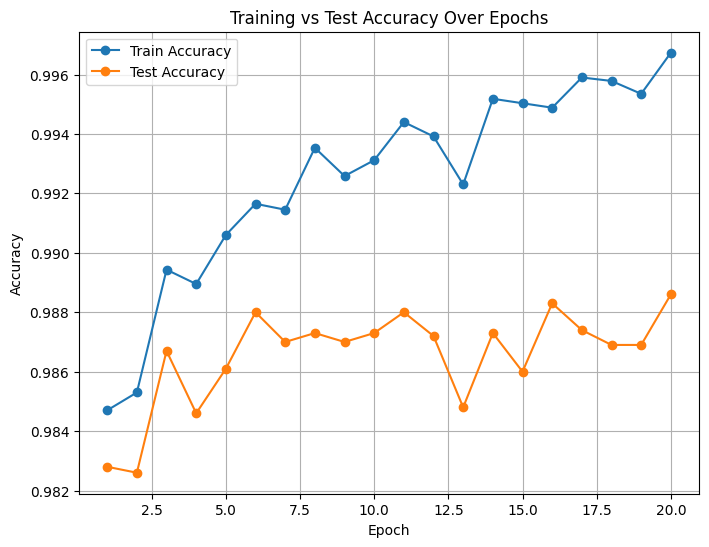

In [ ]:
# Plot Training vs Test Accuracy
plt.figure(figsize=(8, 6))
plt.plot(range(1, epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, epochs+1), test_accuracies, label="Test Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# Evaluation Function
def evaluate(model, data_loader, device, mode="Test"):
    """
    Evaluates the model on the given data_loader and prints accuracy,
    classification report, and confusion matrix.

    Args:
        model: Trained PyTorch model
        data_loader: DataLoader (train or test)
        device: 'cuda' or 'cpu'
        mode: String to indicate 'Train' or 'Test'
    """
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for data, targets in tqdm(data_loader, desc=f"Evaluating {mode}"):
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(targets.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"\n{mode} Accuracy: {acc:.4f}")

    # Classification Report
    print(f"\n{mode} Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{mode} Confusion Matrix')
    plt.show()


Evaluating Train: 100%|██████████| 938/938 [00:07<00:00, 131.08it/s]



Train Accuracy: 0.9967

Train Classification Report:
              precision    recall  f1-score   support

           0     0.9995    0.9973    0.9984      5923
           1     0.9990    0.9961    0.9975      6742
           2     0.9966    0.9987    0.9977      5958
           3     0.9992    0.9928    0.9960      6131
           4     0.9913    0.9991    0.9952      5842
           5     0.9963    0.9972    0.9968      5421
           6     0.9976    0.9997    0.9986      5918
           7     0.9943    0.9976    0.9959      6265
           8     0.9979    0.9962    0.9971      5851
           9     0.9953    0.9928    0.9940      5949

    accuracy                         0.9967     60000
   macro avg     0.9967    0.9968    0.9967     60000
weighted avg     0.9967    0.9967    0.9967     60000



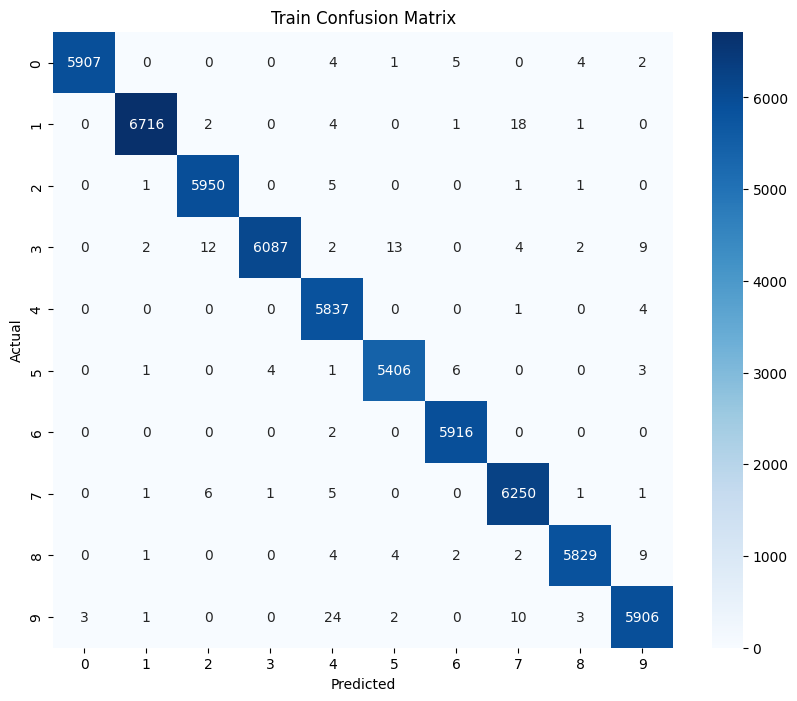

In [18]:
# Evaluate on Training Data
evaluate(model, train_loader, device, mode="Train")

Evaluating Test: 100%|██████████| 157/157 [00:02<00:00, 53.13it/s]



Test Accuracy: 0.9886

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9899    0.9959    0.9929       980
           1     0.9947    0.9921    0.9934      1135
           2     0.9845    0.9864    0.9855      1032
           3     0.9940    0.9891    0.9916      1010
           4     0.9819    0.9929    0.9873       982
           5     0.9943    0.9843    0.9893       892
           6     0.9916    0.9875    0.9895       958
           7     0.9835    0.9883    0.9859      1028
           8     0.9856    0.9867    0.9861       974
           9     0.9861    0.9822    0.9841      1009

    accuracy                         0.9886     10000
   macro avg     0.9886    0.9885    0.9886     10000
weighted avg     0.9886    0.9886    0.9886     10000



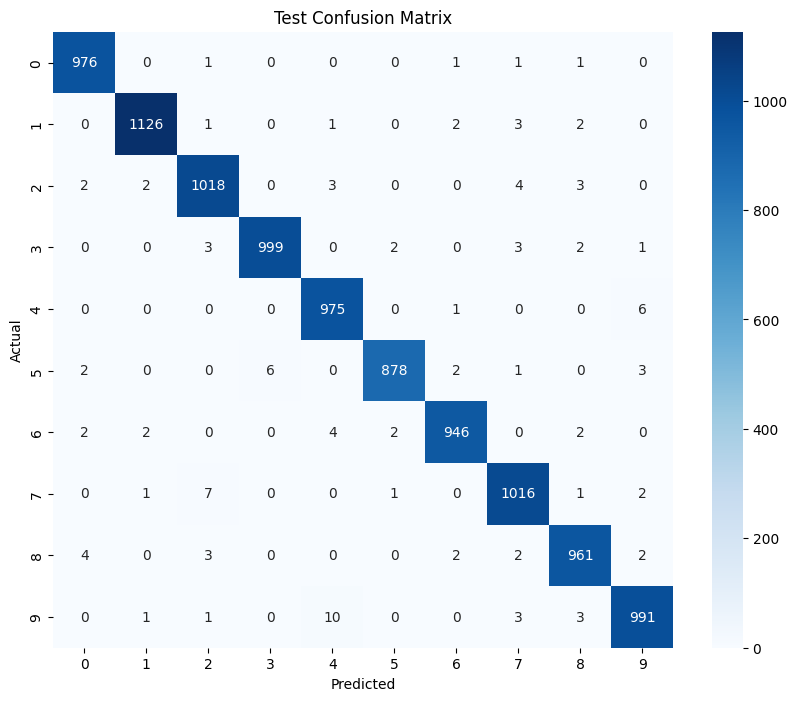

In [19]:
# Evaluate on Test Data
evaluate(model, test_loader, device, mode="Test")